In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


if os.path.split(os.getcwd())[1] == 'Protein_sectors':
    os.chdir('../..')
    
from Scripts.pam_generation import setup_ecoli_pam
from Scripts.pam_generation_uniprot_id import set_up_ecoli_pam as setup_ecoli_pam_up

from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations

Loading PAModelpy modules version 0.0.3.15
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
RXN_NAME_MAPPER = {'EX_ac_e': 'Acetate secretion',
                   'EX_glc__D_e': 'Glucose uptake',
                   'EX_co2_e': '$CO_2$ secretion',
                   'EX_o2_e': 'Oxygen uptake',
                   'BIOMASS_Ec_iML1515_core_75p37M': 'Growth rate [$h^{-1}$]'}
MARKERS = ['.',',','o','v','^','<','>','1','2','3','4','8','s','p','P','*','h','H','+','x','X','D','d','|','_']
ref_data_path = os.path.join('Data', 'Ecoli_phenotypes', 'Ecoli_phenotypes_py_rev.xls')

In [3]:
def calculate_yields_rq(df):
    df['RQ'] = df.EX_co2_e/df.EX_o2_e.abs()
    df['Yxs'] = df.BIOMASS_Ec_iML1515_core_75p37M.abs()/df.EX_glc__D_e.abs()#biomass yield
    df['Yas'] = df.EX_ac_e.abs()/df.EX_glc__D_e.abs() #acetate yield
    return df

## Setup the model and get the reference data

In [5]:
ecoli_pam = setup_ecoli_pam(pam_data_file_path = os.path.join(
    'Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'), sensitivity = False)
ecoli_pam_new = setup_ecoli_pam(pam_data_file_path = os.path.join(
    'Data', 'proteinAllocationModel_iML1515_EnzymaticData_new.xls'), sensitivity = False)
ecoli_pam_uniprot = setup_ecoli_pam_up(sensitivity = False)
ref_data_df = pd.read_excel(ref_data_path, sheet_name='Yields')

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up th

calculate yields and RQ for all the datapoints

In [6]:
ref_data_df = calculate_yields_rq(ref_data_df)

## Perform simulations

In [7]:
substrate_uptake_rates = np.arange(-11, 1, 1)

print('Running simulations for the PAM with the old parameters')
fluxes = run_simulations(ecoli_pam, substrate_uptake_rates)
# fluxes = calculate_yields_rq(fluxes)
print('\n Running simulations for the PAM with the new parameters')
fluxes_new = run_simulations(ecoli_pam_new, substrate_uptake_rates)
# fluxes_new = calculate_yields_rq(fluxes_new)

print('\n Running simulations for the PAM with the new parameters and complex protein-reaction associations')
fluxes_uniprot = run_simulations(ecoli_pam_uniprot, substrate_uptake_rates)

Running simulations for the PAM with the old parameters
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system
Running simulations with  0 mmol/g_cdw/h of substrate going into the system

 Running simulatio

## Plot the simulations

In [52]:
def plot_simulations(valid_data, fluxes, fig=None, grdspc=None, fontsize:int = 12):
    reactions_to_plot = list(RXN_NAME_MAPPER.keys())
    
    # plot flux changes with glucose uptake
    if not fig is None:
        gs = gridspec.GridSpecFromSubplotSpec(2, 1,hspace =0,
                                              subplot_spec=grdspc)
        ax = fig.add_subplot(gs[0,0])
        ax_yield = fig.add_subplot(gs[1,0], sharex=ax)
    else:
        fig, axs = plt.subplots(2, dpi=100)
        fig.set_figwidth(15)
        fig.set_figheight(15)
        ax = axs.flatten()[0]
        ax_yield = axs.flatten()[1]
        
    prop = ax._get_lines.prop_cycler

    cmap = mpl.colormaps['viridis']
    # Take colors at regular intervals spanning the colormap.
    colors = cmap(np.linspace(0, 1, len(reactions_to_plot)+3))
    for i,r in enumerate(reactions_to_plot):
        x = [abs(glc) for glc in valid_data['EX_glc__D_e']]
        y = [abs(data) for data in valid_data[r]]
        xsim = [abs(f['EX_glc__D_e']) for f in fluxes]
        ysim = [abs(f[r]) for f in fluxes]
        
        if 'BIOMASS' in r:
            ax2 = ax.twinx()
            ax2.set_ylabel('Growth rate [$h^(-1)$]', fontsize= fontsize)
            s = ax2.scatter(x, y,
                       color=colors[i], marker=MARKERS[i], s=20,
                       facecolors=None, zorder=0)
            l = ax2.plot(xsim, ysim, linewidth=3,
                       zorder=5, color=colors[i])
            ax.plot([], [], marker=MARKERS[i], color=colors[i], label = RXN_NAME_MAPPER[r])#only the legend handle

            continue
        # plot data
        ax.set_ylabel('Flux rate [$mmol/g_{CDW}/h$]', fontsize= fontsize)
        s = ax.scatter(x, y,
                       color=colors[i], marker=MARKERS[i], s=20,
                       facecolors=None, zorder=0)
        l = ax.plot(xsim, ysim, linewidth=3,
                       zorder=5, color=colors[i])
        ax.plot([], [], marker=MARKERS[i], color=colors[i], label = RXN_NAME_MAPPER[r])#only the legend handle
        ax.set_xlabel(RXN_NAME_MAPPER['EX_glc__D_e'], fontsize= fontsize)
        ax.tick_params(axis='both',labelsize = fontsize)
#         ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.1f'))

    rqsim = [abs(f['EX_co2_e']/f['EX_o2_e']) for f in fluxes]
    yassim = [abs(f['EX_ac_e']/f['EX_glc__D_e']) for f in fluxes]
    yxssim = [abs(f['BIOMASS_Ec_iML1515_core_75p37M']/f['EX_glc__D_e']) for f in fluxes]
    ax_yield.plot(xsim, rqsim, color=colors[i+1],  linewidth=3,
                       zorder=0,
                       label='Respiratory coefficient')# ($q_{co2}/q_{o2}$)')
    ax_yield.scatter(x, [abs(data) for data in valid_data['RQ']],
                       color=colors[i+1], marker=MARKERS[i], s=20,
                       facecolors=None, zorder=0)
    ax_yield.plot(xsim, yassim, color=colors[i+2],  linewidth=3,
                       zorder=0,
                       label='Acetate yield on substrate')# ($\frac{mmol_{ac}}{mmol_{s}}$)')
    ax_yield.scatter(x, [abs(data) for data in valid_data['Yas']],
                       color=colors[i+2], marker=MARKERS[i-1], s=20,
                       facecolors=None, zorder=0)
    ax_yield.plot(xsim, yxssim, color=colors[i+3], linewidth=3,
                       zorder=0,
                       label='Biomass yield on substrate')# ($\frac{g_{CDW}}{mmol_{s}}$)')
    ax_yield.scatter(x, [abs(data) for data in valid_data['Yxs']],
                       color=colors[i+3], marker=MARKERS[i-2], s=20,
                       facecolors=None, zorder=0)
    ax_yield.set_xlabel(RXN_NAME_MAPPER['EX_glc__D_e'], fontsize= fontsize)
    ax_yield.set_ylabel('Yield/RQ', fontsize= fontsize)
    ax_yield.legend()
    
     #After plotting line graphs in ax
    handles_ax, labels_ax = ax.get_legend_handles_labels()

    # After plotting line graphs in ax_yield
    handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()

    # Combine handles and labels from both subfigures
    combined_handles = handles_ax
    
    combined_labels = labels_ax

    # Create a combined legend
    ax.legend(combined_handles,labels_ax, loc='upper left')    
#     ax2.get_legend().remove()
    
    plt.legend()
    fig.tight_layout()
    fig.show()

    return fig


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


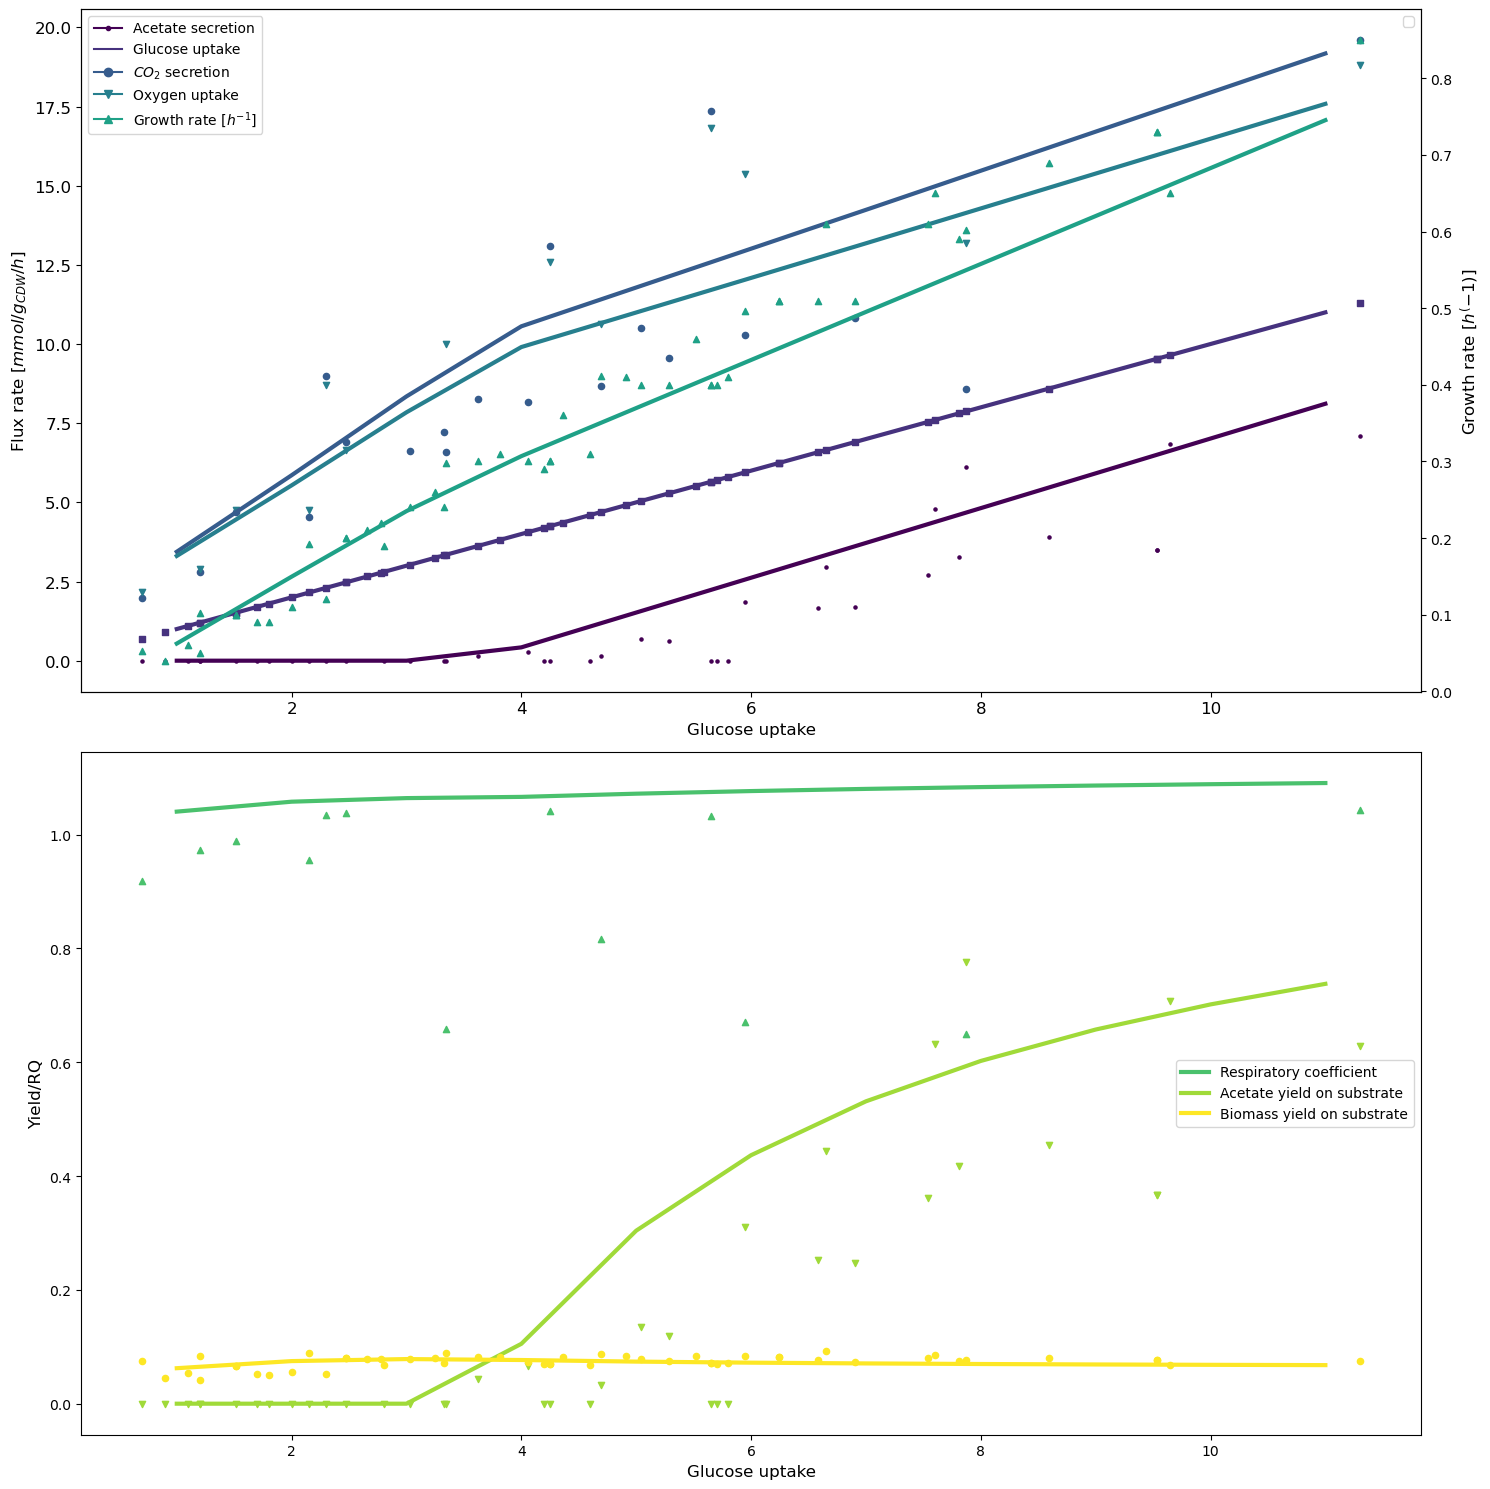

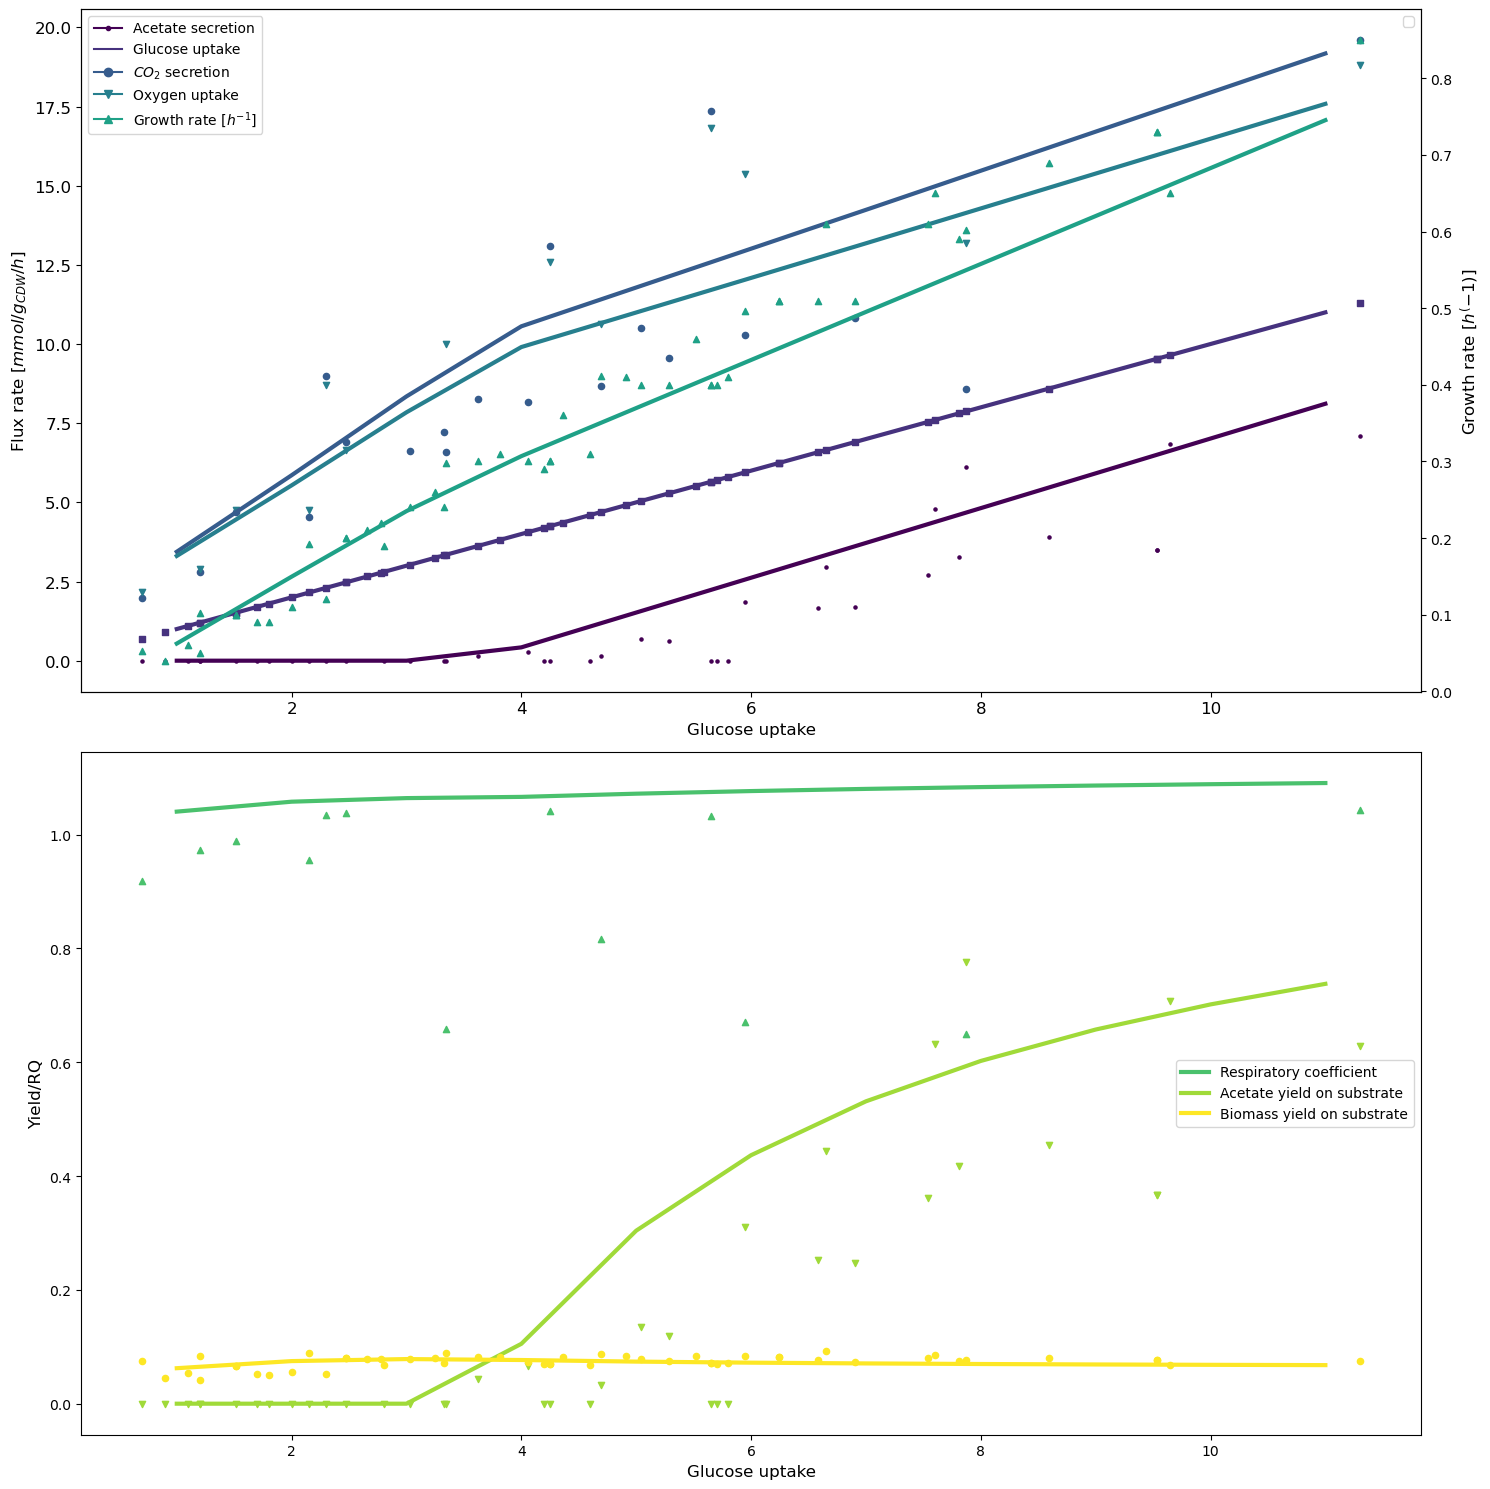

In [38]:
plot_simulations(ref_data_df, fluxes)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


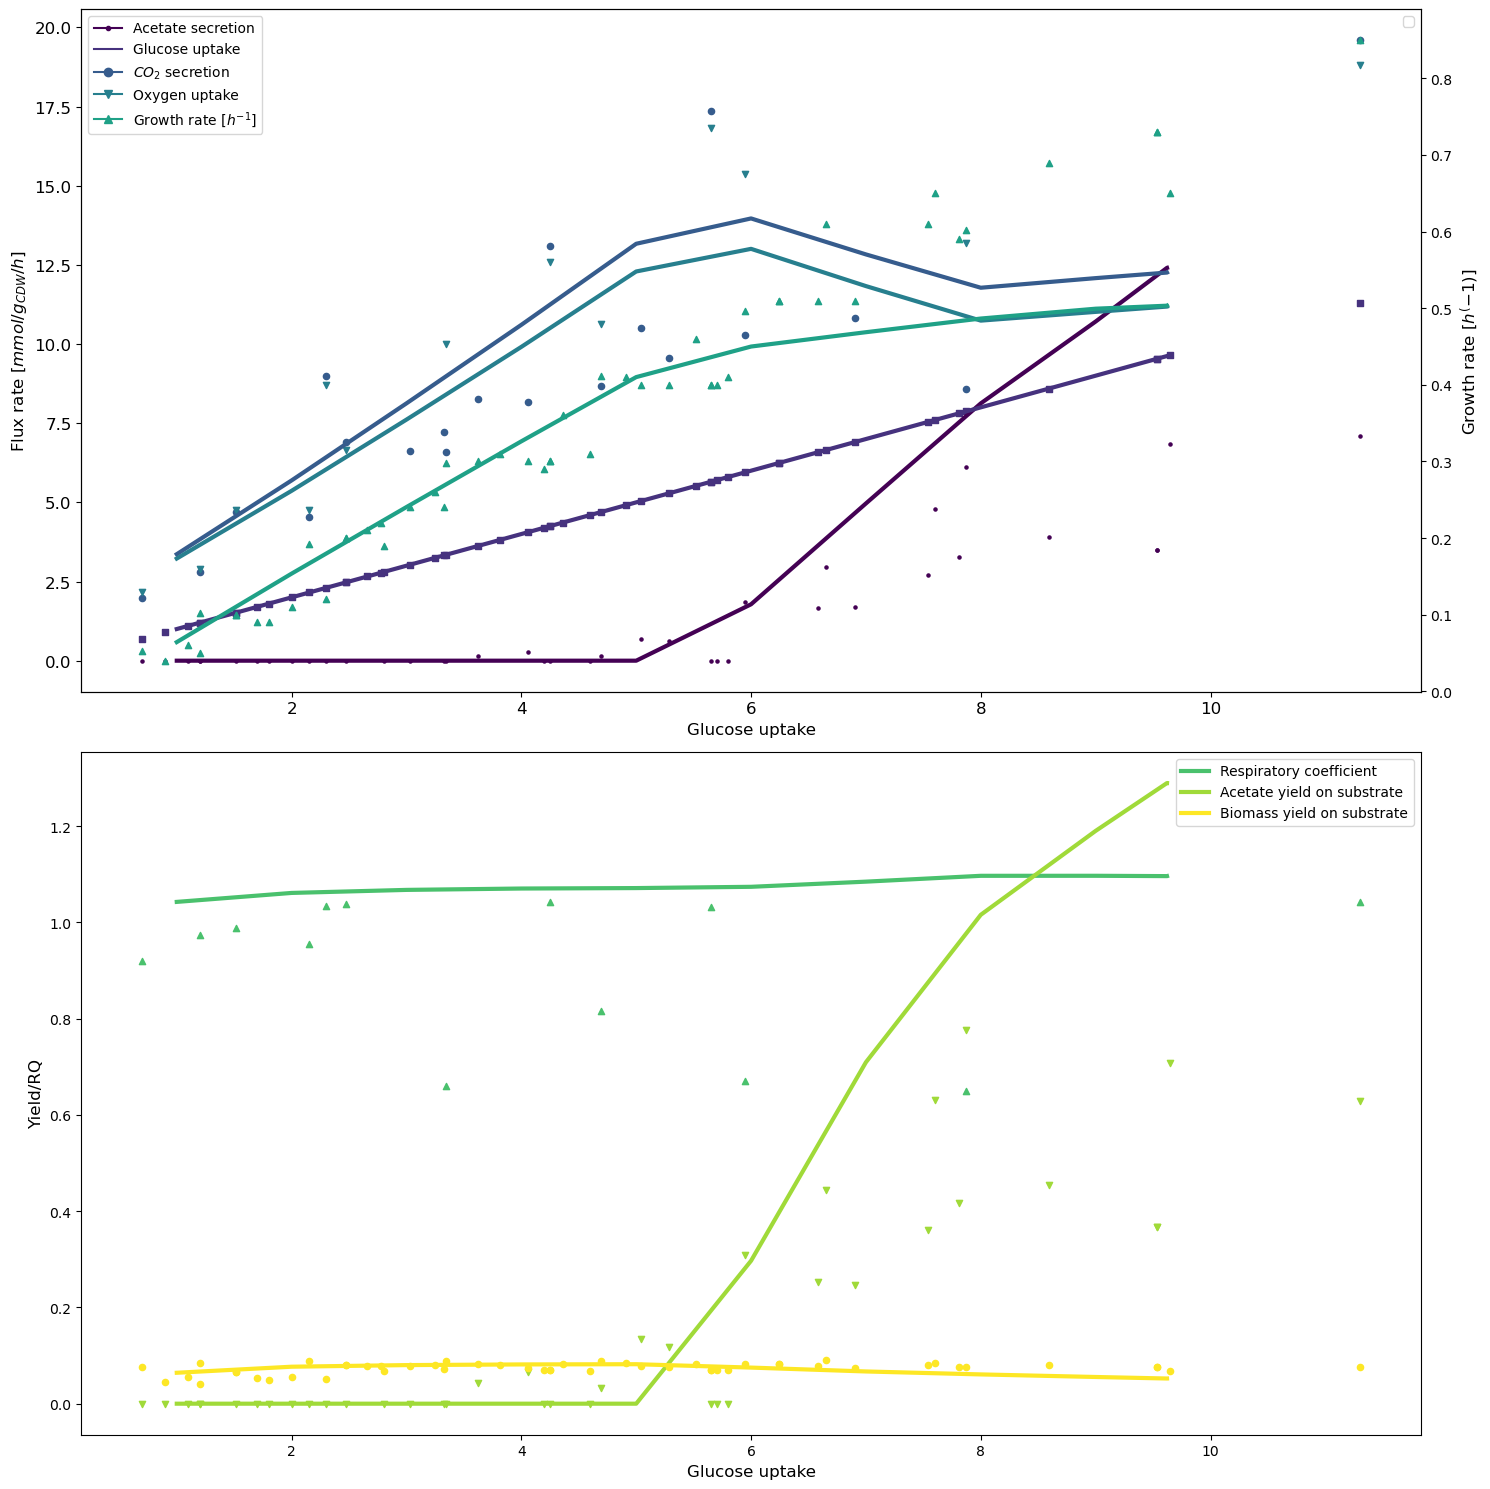

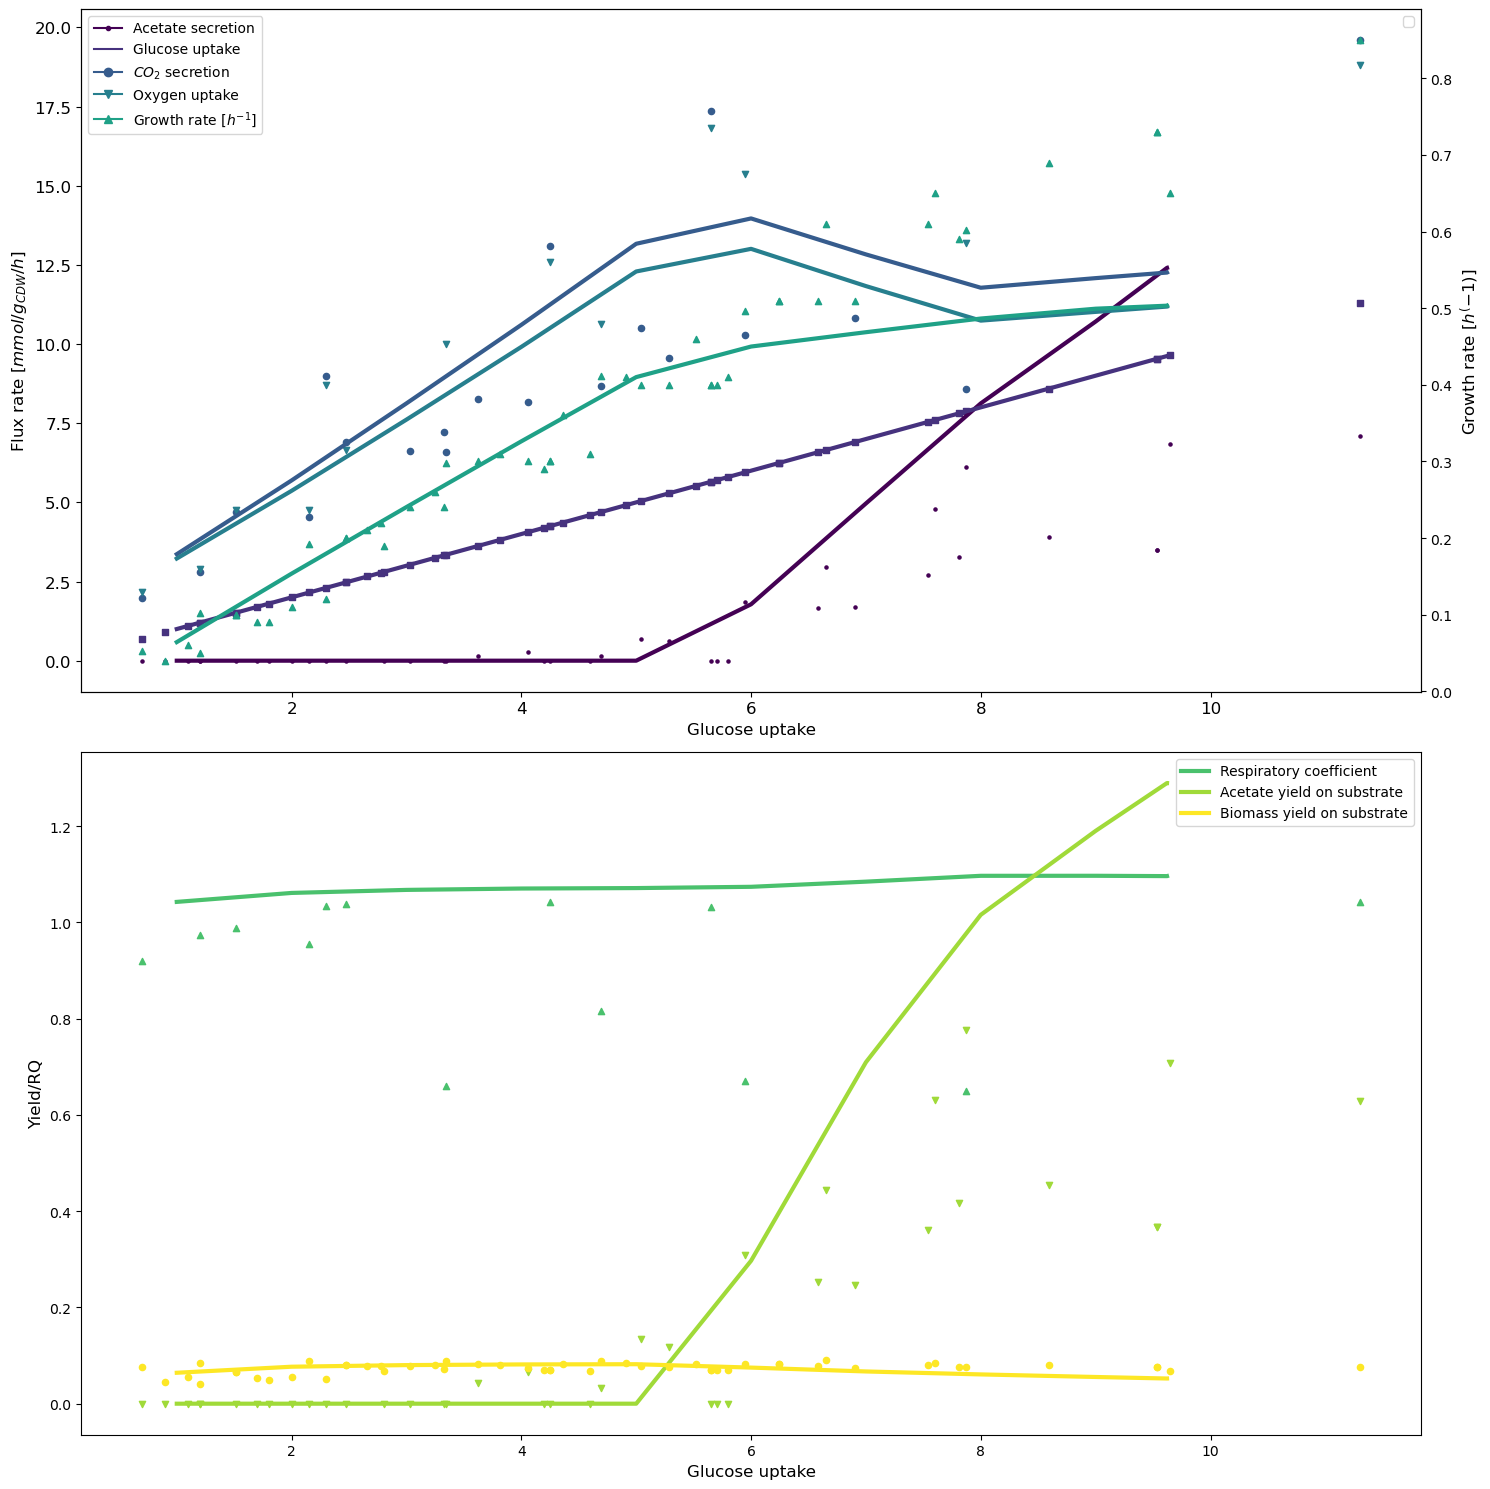

In [39]:
plot_simulations(ref_data_df, fluxes_new)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


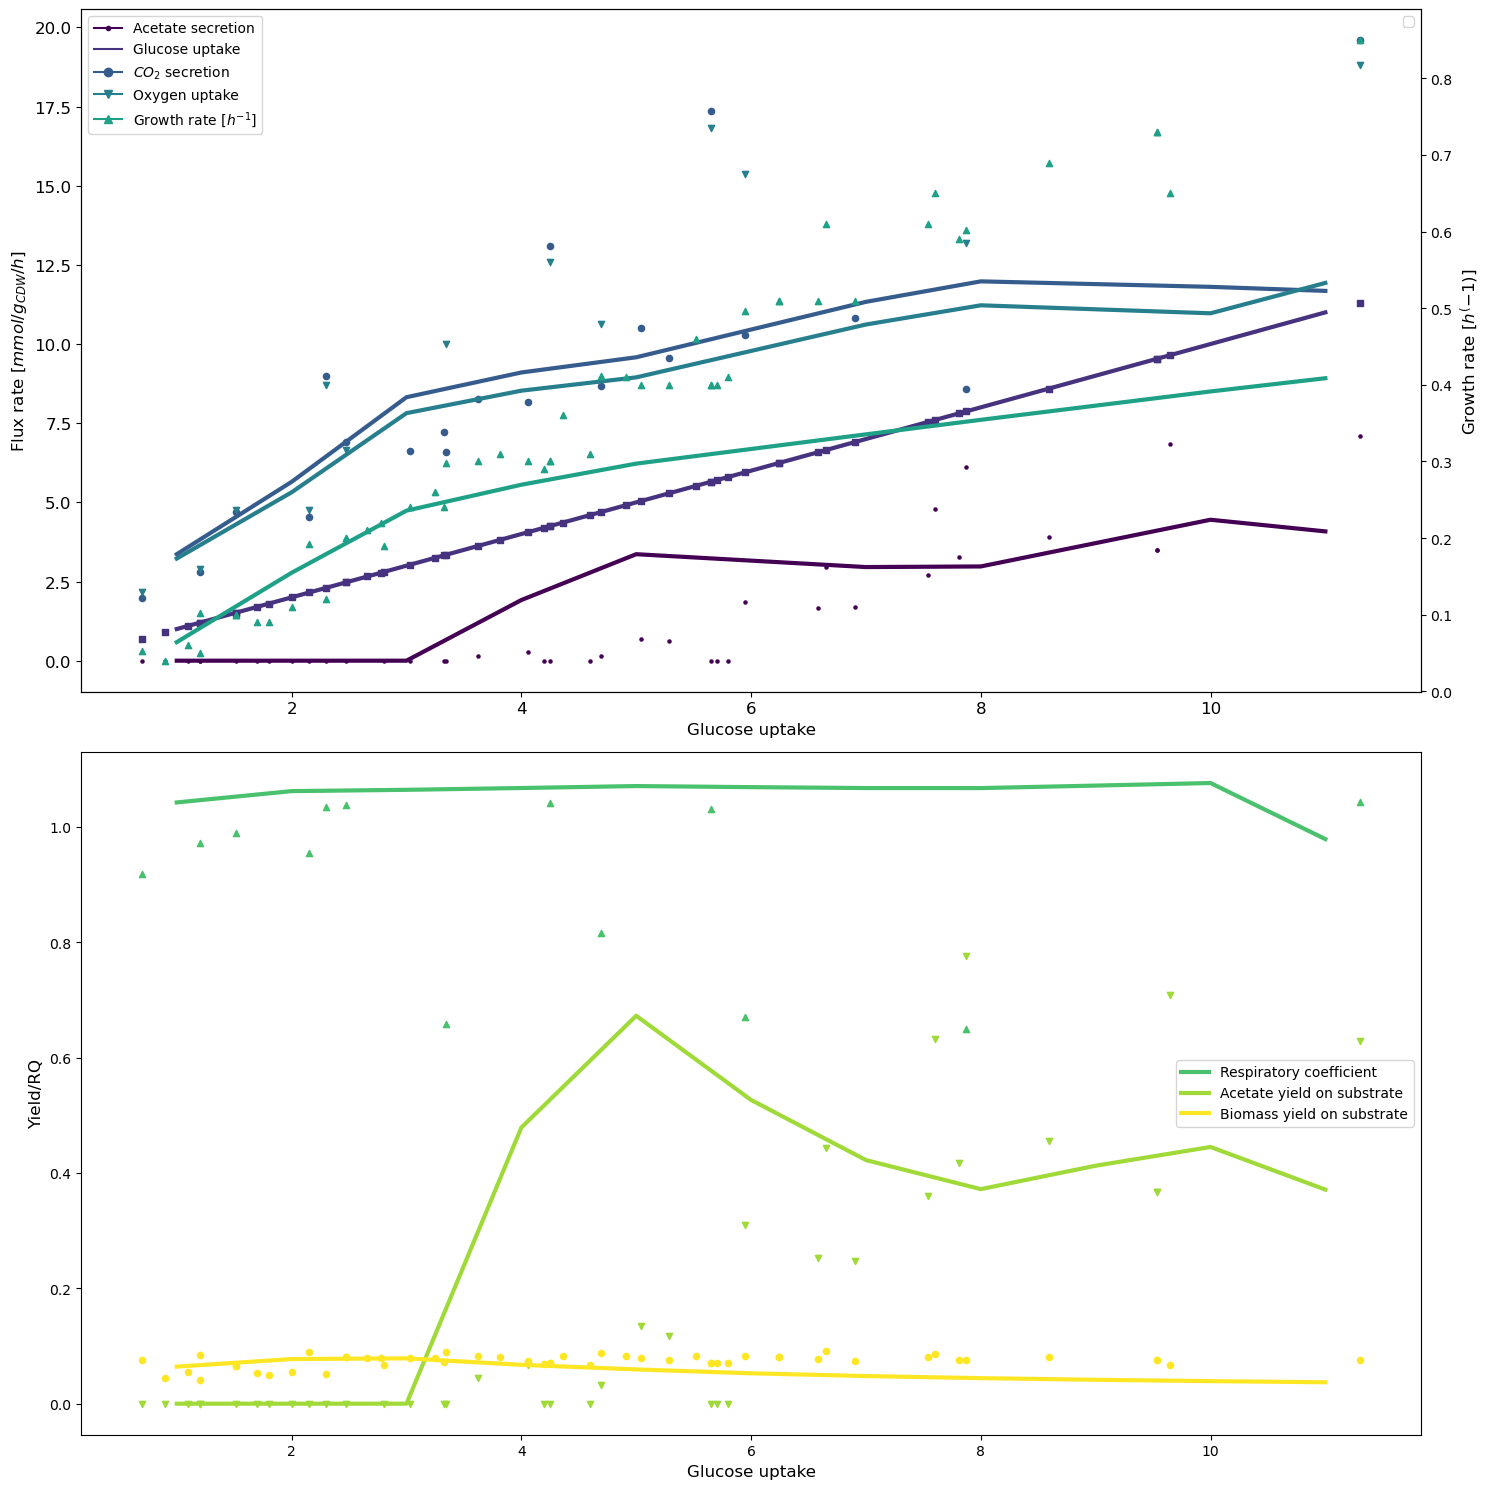

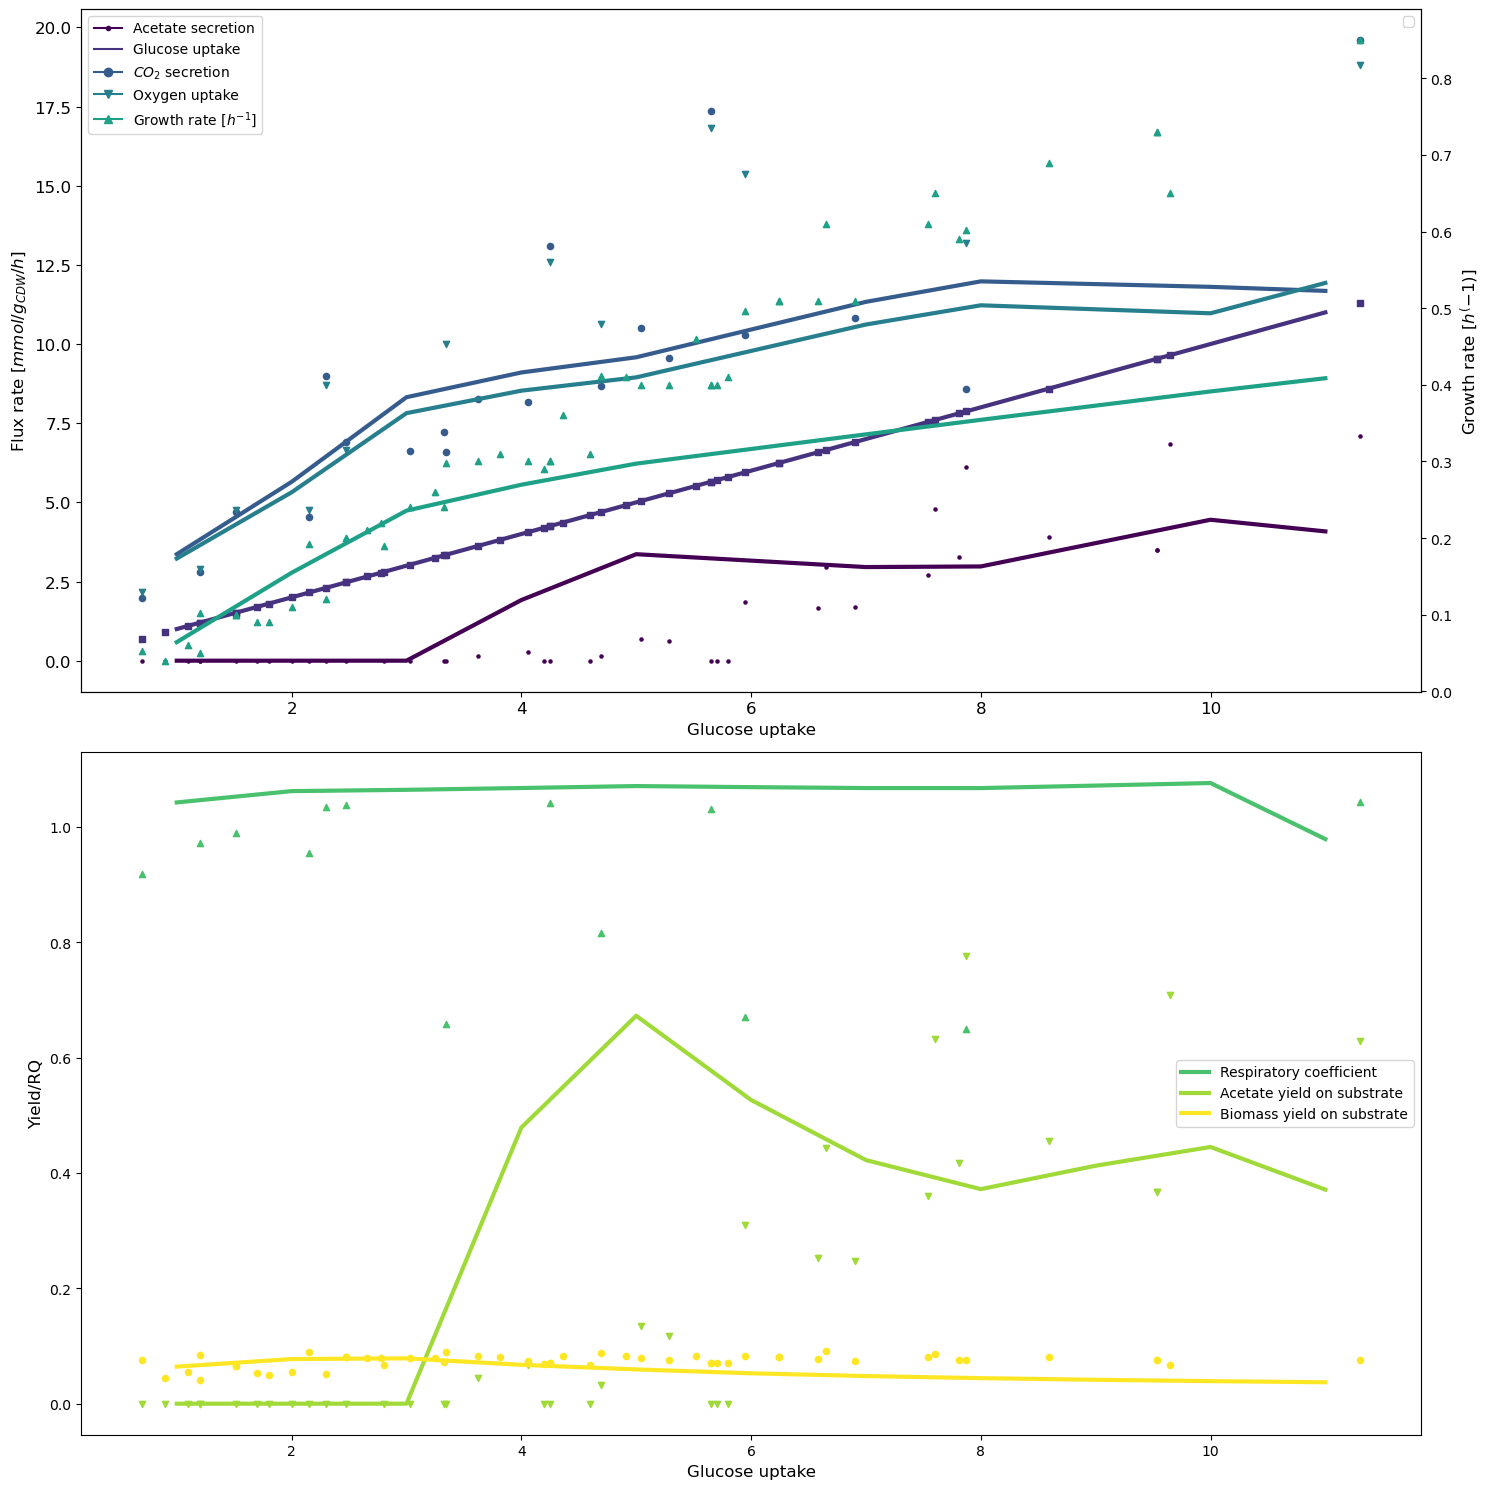

In [40]:
plot_simulations(ref_data_df, fluxes_uniprot)

## Create one big figure to save

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


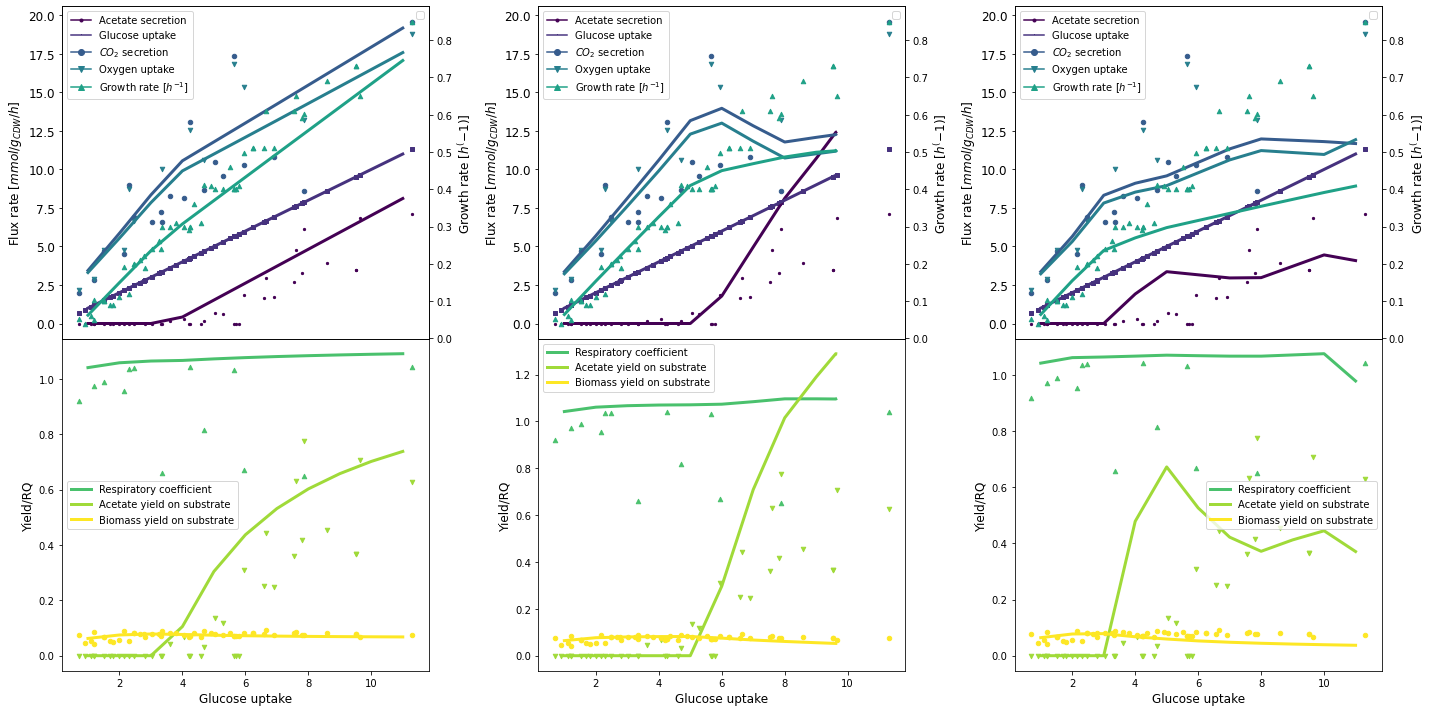

In [53]:
fig = plt.figure()

fig.set_figwidth(20)
fig.set_figheight(10)

gs0 = gridspec.GridSpec(1, 3, figure=fig)
for i, flux_df in enumerate([fluxes, fluxes_new, fluxes_uniprot]):
    gs = gs0[0,i]
    plot_simulations(ref_data_df, flux_df, fig, gs)
        
    
fig.show()